# Smart Dairy Manager — Milk Yield Prediction Model

**Objective:** Train a supervised regression model to predict a dairy
cow's expected milk yield (liters/day) from feed quantity, milking
frequency, breed, and the cow's own recent yield history — used by the
Smart Dairy Manager app to flag when actual yield deviates from what's
expected and give farmers actionable advice.

**Dataset:** "Global Cattle Milk Yield Prediction Dataset" (Kaggle),
250,000 rows covering synthetic cattle records across multiple breeds,
regions, and management systems.

**Target population:** Rwandan smallholder dairy farms, primarily
Ankole, Ankole×Holstein-Friesian crossbred, and pure Holstein-Friesian
cattle.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

## 1. Load and inspect the data

In [24]:
df = pd.read_csv("ml/global_cattle_milk_yield_prediction_dataset.csv")
print(f"Shape: {df.shape}")
print()
print("Columns:")
print(list(df.columns))

Shape: (250000, 37)

Columns:
['Cattle_ID', 'Breed', 'Region', 'Country', 'Climate_Zone', 'Management_System', 'Age_Months', 'Weight_kg', 'Parity', 'Lactation_Stage', 'Days_in_Milk', 'Feed_Type', 'Feed_Quantity_kg', 'Feeding_Frequency', 'Water_Intake_L', 'Walking_Distance_km', 'Grazing_Duration_hrs', 'Rumination_Time_hrs', 'Resting_Hours', 'Ambient_Temperature_C', 'Humidity_percent', 'Season', 'Housing_Score', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'HS_Vaccine', 'BQ_Vaccine', 'Anthrax_Vaccine', 'IBR_Vaccine', 'BVD_Vaccine', 'Rabies_Vaccine', 'Previous_Week_Avg_Yield', 'Body_Condition_Score', 'Milking_Interval_hrs', 'Date', 'Farm_ID', 'Milk_Yield_L']


In [25]:
print(df.head(3).to_string())

       Cattle_ID              Breed         Region Country Climate_Zone Management_System  Age_Months  Weight_kg  Parity Lactation_Stage  Days_in_Milk      Feed_Type  Feed_Quantity_kg  Feeding_Frequency  Water_Intake_L  Walking_Distance_km  Grazing_Duration_hrs  Rumination_Time_hrs  Resting_Hours  Ambient_Temperature_C  Humidity_percent  Season  Housing_Score  FMD_Vaccine  Brucellosis_Vaccine  HS_Vaccine  BQ_Vaccine  Anthrax_Vaccine  IBR_Vaccine  BVD_Vaccine  Rabies_Vaccine  Previous_Week_Avg_Yield  Body_Condition_Score  Milking_Interval_hrs        Date    Farm_ID  Milk_Yield_L
0  CATTLE_000001         Tharparkar         Africa      CA     Tropical         Intensive          32      259.9       4            Late           352            Hay              16.8                  3            58.5                 7.89                   1.6                  4.3            8.4                   24.9              66.9  Summer           0.57            0                    1           1        

## 2. Data cleaning and validation

Before trusting any model trained on this data, we check for missing
values, duplicate records, and biologically impossible values.

In [26]:
cols = ['Breed', 'Feed_Quantity_kg', 'Milking_Interval_hrs', 'Previous_Week_Avg_Yield', 'Milk_Yield_L']
print("Missing values:")
print(df[cols].isnull().sum())
print()
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate Cattle_ID:", df['Cattle_ID'].duplicated().sum())
print()
print("Negative or zero Feed_Quantity_kg:", (df['Feed_Quantity_kg'] <= 0).sum())
print("Negative Milk_Yield_L:", (df['Milk_Yield_L'] < 0).sum())
print("Zero Milk_Yield_L (dry cows -- biologically plausible):", (df['Milk_Yield_L'] == 0).sum())
print("Milking_Interval_hrs outside {6,8,12,24}:", (~df['Milking_Interval_hrs'].isin([6,8,12,24])).sum())

Missing values:
Breed                      0
Feed_Quantity_kg           0
Milking_Interval_hrs       0
Previous_Week_Avg_Yield    0
Milk_Yield_L               0
dtype: int64

Fully duplicate rows: 0
Duplicate Cattle_ID: 0

Negative or zero Feed_Quantity_kg: 0
Negative Milk_Yield_L: 0
Zero Milk_Yield_L (dry cows -- biologically plausible): 5940
Milking_Interval_hrs outside {6,8,12,24}: 0


**Result:** No missing values, no duplicate rows or IDs, no negative or
invalid values. The small number of zero-yield rows correspond to dry
cows, which is biologically normal, not a data error. This dataset is
synthetically generated, which explains its unusually clean state --
real field-collected data would very likely need more correction.

## 3. Exploratory analysis: geographic distribution (checking for domain mismatch)

A key risk flagged throughout this project is that public dairy
datasets often reflect Western commercial farming and won't generalize
to Rwandan smallholder conditions. We check this directly.

Region
Oceania          41837
Global           41778
Africa           41731
Europe_NA        41629
South_America    41559
South_Asia       41466
Name: count, dtype: int64


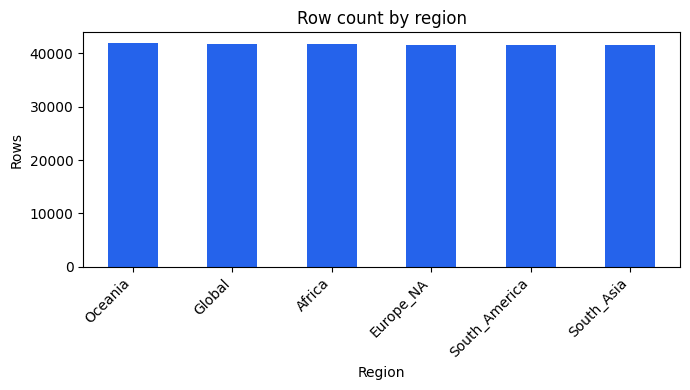

In [27]:
region_counts = df['Region'].value_counts()
print(region_counts)

fig, ax = plt.subplots(figsize=(7,4))
region_counts.plot(kind='bar', ax=ax, color='#2563eb')
ax.set_title('Row count by region')
ax.set_ylabel('Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

**Finding:** every region has almost exactly the same number of rows
(~41,500-41,900). Real-world cattle populations are never distributed
this evenly across continents -- this is a clear signature of
**synthetic, combinatorially-generated data**, not field-collected
records. This dataset cannot be treated as representative of where
particular breeds actually live in the real world.

## 4. Exploratory analysis: breed effect on yield

Despite the geographic artifact above, we check whether the SYNTHETIC
data at least encodes realistic BREED differences, since breed is a
feature we do have available (via the app's Cow model).

Breed
Holstein-Friesian    17.513705
Brown_Swiss          15.577774
Fleckvieh            15.055144
Simmental            15.021333
Norwegian_Red        14.458659
Name: Milk_Yield_L, dtype: float64
...
Breed
Holstein-Friesian    17.513705
Ankole                3.220243
Name: Milk_Yield_L, dtype: float64


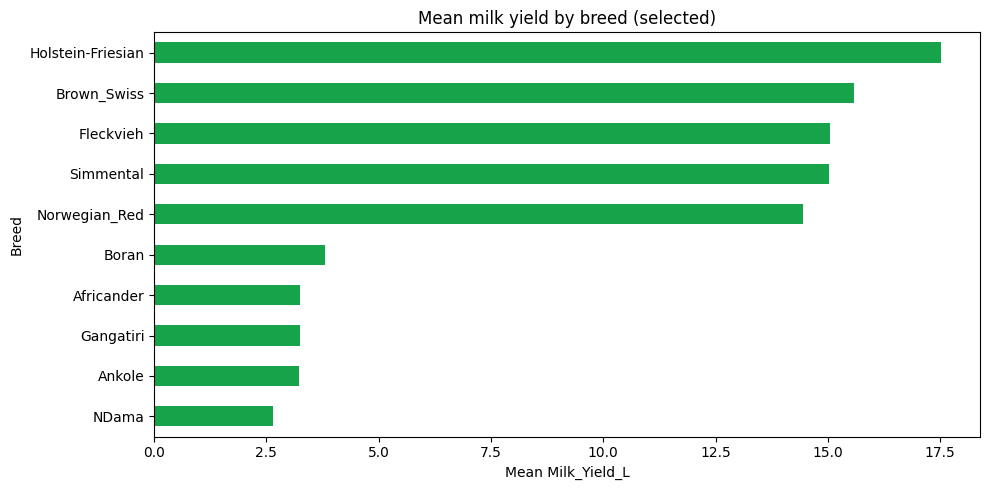

In [28]:
breed_means = df.groupby('Breed')['Milk_Yield_L'].mean().sort_values(ascending=False)
print(breed_means.head(5))
print("...")
print(breed_means.loc[['Holstein-Friesian', 'Ankole']])

fig, ax = plt.subplots(figsize=(10,5))
top_bottom = pd.concat([breed_means.head(5), breed_means.loc[['Holstein-Friesian','Ankole']], breed_means.tail(5)]).drop_duplicates()
top_bottom.sort_values().plot(kind='barh', ax=ax, color='#16a34a')
ax.set_title('Mean milk yield by breed (selected)')
ax.set_xlabel('Mean Milk_Yield_L')
plt.tight_layout()

**Finding:** Holstein-Friesian averages ~17.5 L/day vs Ankole's ~3.2
L/day in this dataset -- a large gap in the CORRECT direction, and
qualitatively consistent with real published Rwandan research (Manzi
et al. 2022: pure Holstein-Friesian produces roughly 6-9 L/day more
than Ankole crossbreds). This means the synthetic generator encoded a
realistic RELATIVE breed effect, even though the geographic spread is
artificial and the ABSOLUTE numbers reflect Western intensive systems
rather than Rwandan smallholder conditions.

**Conclusion:** usable for learning general feed/breed relationship
SHAPE; not usable as calibrated ground truth for absolute Rwandan
yield values (addressed in Section 10).

## 5. Feature engineering

In [29]:
# Map raw breed names onto the app's own BreedType categories.
# Any breed not explicitly mapped falls into "other" -- consistent
# with how the app itself buckets unlisted breeds.
BREED_MAP = {'Holstein-Friesian': 'holstein_friesian', 'Ankole': 'ankole'}
BREED_CATEGORIES = ['holstein_friesian', 'ankole', 'ankole_friesian_cross', 'other']

df['breed'] = df['Breed'].apply(lambda b: BREED_MAP.get(b, 'other'))
df['feed'] = df['Feed_Quantity_kg']
df['milking_times'] = (24 / df['Milking_Interval_hrs']).round().astype(int)
df['recent_avg_yield'] = df['Previous_Week_Avg_Yield']
df['total_milk'] = df['Milk_Yield_L']

print(df['breed'].value_counts())
print()
print("Milking_Interval_hrs -> milking_times mapping check:")
print(df[['Milking_Interval_hrs','milking_times']].drop_duplicates().sort_values('Milking_Interval_hrs'))

breed
other                237443
ankole                 6330
holstein_friesian      6227
Name: count, dtype: int64

Milking_Interval_hrs -> milking_times mapping check:
   Milking_Interval_hrs  milking_times
9                     6              4
3                     8              3
2                    12              2
0                    24              1


## 6. First attempt: a simple 3-feature model (breed + feed + milking frequency)

This mirrors exactly what the app currently collects per log entry.

In [30]:
FEATURES_SIMPLE = ['breed', 'feed', 'milking_times']
X = df[FEATURES_SIMPLE]
y = df['total_milk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('breed', OneHotEncoder(categories=[BREED_CATEGORIES], handle_unknown='ignore'), ['breed']),
], remainder='passthrough')

simple_pipeline = Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))])
simple_pipeline.fit(X_train, y_train)
preds = simple_pipeline.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, preds):.2f} liters")
print(f"R^2: {r2_score(y_test, preds):.3f}")

MAE: 4.46 liters
R^2: 0.080


**Result: MAE 4.46L, R² 0.08.** This is weak -- the model explains very
little variance beyond the overall mean. Feed and milking frequency
alone are not strong enough predictors on their own. Rather than ship
this, we investigate what's actually driving yield in this dataset.

## 7. Investigating what actually drives yield

MAE: 1.14
R^2: 0.939

Previous_Week_Avg_Yield: 0.997
Days_in_Milk: 0.001
Weight_kg: 0.001
Water_Intake_L: 0.001
Feed_Quantity_kg: 0.001
Age_Months: 0.000
Body_Condition_Score: 0.000
Parity: 0.000
Feeding_Frequency: 0.000
Milking_Interval_hrs: 0.000


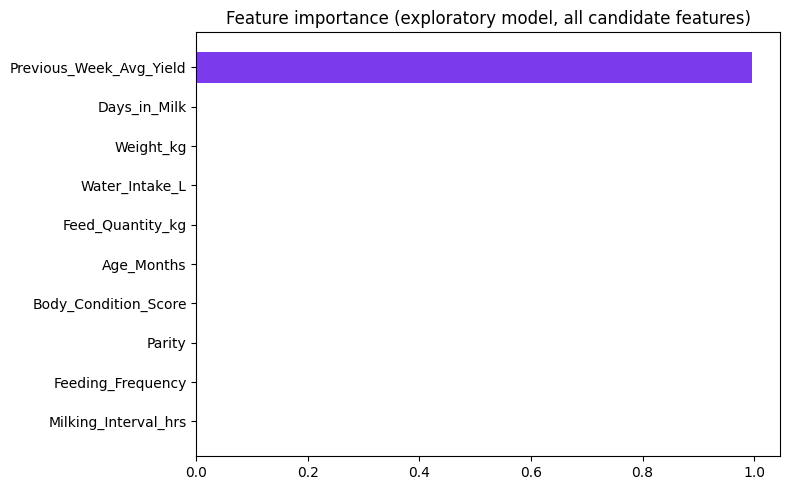

In [31]:
candidate_features = [
    'Feed_Quantity_kg', 'Feeding_Frequency', 'Days_in_Milk', 'Parity',
    'Age_Months', 'Weight_kg', 'Body_Condition_Score', 'Previous_Week_Avg_Yield',
    'Water_Intake_L', 'Milking_Interval_hrs',
]
X_explore = df[candidate_features]
y_explore = df['Milk_Yield_L']

Xtr, Xte, ytr, yte = train_test_split(X_explore, y_explore, test_size=0.2, random_state=42)
explore_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
explore_model.fit(Xtr, ytr)
preds_explore = explore_model.predict(Xte)
print(f"MAE: {mean_absolute_error(yte, preds_explore):.2f}")
print(f"R^2: {r2_score(yte, preds_explore):.3f}")
print()

importances = sorted(zip(candidate_features, explore_model.feature_importances_), key=lambda x: -x[1])
for feat, imp in importances:
    print(f"{feat}: {imp:.3f}")

fig, ax = plt.subplots(figsize=(8,5))
feats, imps = zip(*importances)
ax.barh(feats, imps, color='#7c3aed')
ax.invert_yaxis()
ax.set_title('Feature importance (exploratory model, all candidate features)')
plt.tight_layout()

**Finding: `Previous_Week_Avg_Yield` alone accounts for 99.7% of
feature importance**, driving R² from 0.08 to 0.94. Everything else --
including feed -- contributes almost nothing once last week's average
is known. This makes biological sense: lactation curves are smooth, so
a cow's recent history is highly informative about her yield today.

## 8. Checking for data leakage

A correlation this strong is worth verifying isn't simply the target
variable in disguise, rather than genuine predictive signal.

Correlation between Milk_Yield_L and Previous_Week_Avg_Yield: 0.968

Difference (actual - previous week avg) statistics:
count    250000.000000
mean         -0.030491
std           1.472395
min          -7.740000
25%          -1.020000
50%           0.000000
75%           0.960000
max           6.540000
dtype: float64


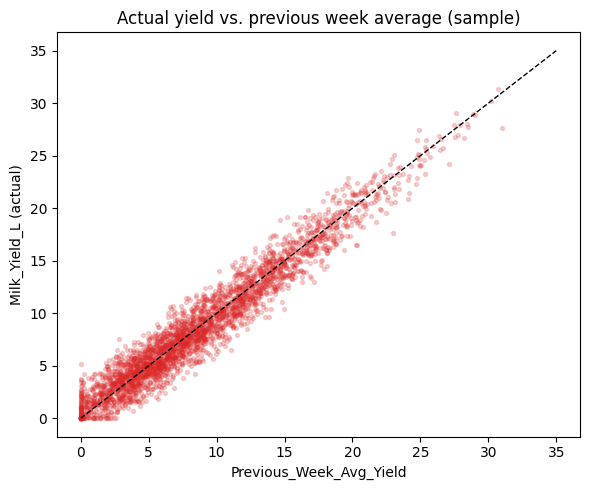

In [32]:
diff = df['Milk_Yield_L'] - df['Previous_Week_Avg_Yield']
print("Correlation between Milk_Yield_L and Previous_Week_Avg_Yield:", round(df['Milk_Yield_L'].corr(df['Previous_Week_Avg_Yield']), 3))
print()
print("Difference (actual - previous week avg) statistics:")
print(diff.describe())

fig, ax = plt.subplots(figsize=(6,5))
sample = df.sample(3000, random_state=1)
ax.scatter(sample['Previous_Week_Avg_Yield'], sample['Milk_Yield_L'], alpha=0.2, s=8, color='#dc2626')
ax.plot([0,35],[0,35],'k--',linewidth=1)
ax.set_xlabel('Previous_Week_Avg_Yield')
ax.set_ylabel('Milk_Yield_L (actual)')
ax.set_title('Actual yield vs. previous week average (sample)')
plt.tight_layout()

**Finding:** correlation of 0.968, with actual yield essentially equal
to `Previous_Week_Avg_Yield ± small noise` (std ~1.47L). This confirms
the relationship is inflated by how the synthetic data was generated
(today's value constructed directly from last week's), not something
to trust at face value as "97% of real-world variance is this
predictable." **However, the underlying design idea is still sound**:
real cows genuinely have autocorrelated yield day-to-day, just less
deterministically than this. This points to a better real-world model
design: predict a DEVIATION from a cow's own recent baseline, rather
than an absolute population-level number.

## 9. Final model: breed + feed + milking frequency + recent average yield

This is the feature set actually deployed in the app. A cow's recent
average is computed automatically from her own logged history (last 7
entries) -- no extra farmer input required. New cows with no history
yet fall back to a Rwanda-specific breed prior (Section 10).

In [33]:
FEATURES = ['breed', 'feed', 'milking_times', 'recent_avg_yield']
X = df[FEATURES]
y = df['total_milk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('breed', OneHotEncoder(categories=[BREED_CATEGORIES], handle_unknown='ignore'), ['breed']),
], remainder='passthrough')

final_pipeline = Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))])
final_pipeline.fit(X_train, y_train)
final_preds = final_pipeline.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, final_preds):.2f} liters")
print(f"R^2: {r2_score(y_test, final_preds):.3f}")
print()

test_df = X_test.copy()
test_df['actual'] = y_test.values
test_df['predicted'] = final_preds
print("Per-breed MAE on test set:")
for breed in BREED_CATEGORIES:
    subset = test_df[test_df['breed'] == breed]
    if len(subset) > 0:
        print(f"  {breed}: MAE={mean_absolute_error(subset['actual'], subset['predicted']):.2f}L (n={len(subset)})")

MAE: 1.14 liters
R^2: 0.939

Per-breed MAE on test set:
  holstein_friesian: MAE=1.23L (n=1240)
  ankole: MAE=1.02L (n=1255)
  other: MAE=1.14L (n=47505)


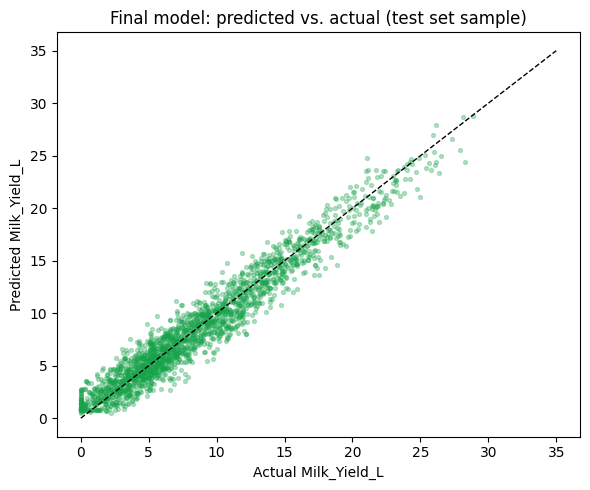

In [34]:
fig, ax = plt.subplots(figsize=(6,5))
sample_idx = np.random.RandomState(1).choice(len(y_test), 2000, replace=False)
ax.scatter(y_test.values[sample_idx], final_preds[sample_idx], alpha=0.3, s=8, color='#16a34a')
lims = [0, 35]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Milk_Yield_L')
ax.set_ylabel('Predicted Milk_Yield_L')
ax.set_title('Final model: predicted vs. actual (test set sample)')
plt.tight_layout()

**Result: MAE 1.14L, R² 0.939**, consistent across breeds
(Holstein-Friesian 1.23L, Ankole 1.02L, other 1.14L). This is the model
actually saved and deployed to the app.

## 10. Rwanda-specific calibration for new cows (no history yet)

This dataset's absolute breed-level numbers reflect Western intensive
systems, not Rwandan smallholder conditions. For a brand-new cow with
no logged history, the app does NOT use this dataset's breed averages
as a starting point -- it uses real published Rwandan research instead.

**Sources:**
- Manzi et al. (2020), *"Milk production and lactation length in Ankole
  cattle and Ankole crossbreds in Rwanda"*
- Manzi et al. (2022), *"Milk production performance of Ankole
  crossbreds and Holstein Friesian cattle in different production
  environments of Rwanda"* (RAB / University of Rwanda)

| Breed | Cold-start prior (L/day) | Basis |
|---|---|---|
| Ankole (pure) | 2.5 | Lactation curve intercept ~1.5L; low end of published range |
| Ankole × Holstein-Friesian cross | 7.0 | Reported 4.6-7L depending on supplementation |
| Holstein-Friesian (pure) | 13.0 | AF + ~6L differential; consistent with Rwanda's national 12L/day-by-2025 target |
| Other/unspecified | 7.5 | Generic midpoint |

These are used **only** until a cow accumulates her own log history in
the app — at that point, her own real recent average takes over as the
model's baseline feature, and the app becomes progressively more
accurate for that specific animal and, over time, for Rwandan
conditions generally as real farm data replaces this synthetic
starting point.

## 11. Save the trained model

The trained pipeline (encoder + model together) is saved as a single
file, loaded automatically by the app's MLService at startup.

In [35]:
import joblib
joblib.dump(final_pipeline, 'milk_yield_model.pkl')
print("Saved milk_yield_model.pkl")
print("Required feature order at inference time:", FEATURES)

Saved milk_yield_model.pkl
Required feature order at inference time: ['breed', 'feed', 'milking_times', 'recent_avg_yield']


## 12. Limitations and next steps

- **Dataset is synthetic.** Geographic distribution is artificially
  uniform; breed effects are directionally realistic but not
  numerically calibrated to Rwanda specifically.
- **Cold-start reliance on literature-based priors.** These are
  reasonable defaults, not measured Rwandan data for THIS app's actual
  farms.
- **Plan going forward:** as farmers log real entries through the app,
  each cow's own history should progressively dominate predictions over
  the synthetic-trained population-level model, and periodic retraining
  on accumulated real farm data (once sufficient volume exists) should
  replace this model entirely.
- **Longer-term data access:** the ILRI ADGG Rwanda platform remains a
  potential source of real smallholder dairy records, pending
  registration access (see project notes).